# **CODSOFT TASK 4**

**Spam SMS Detection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/CodSoft DATASETS/spam.csv", encoding="latin-1")
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


**Data Cleaning and Feature Selection**

In [ ]:
df = df.iloc[:, :2].copy()

In [ ]:
df.columns = ['Label', 'Message']

**Check Missing Values**

In [ ]:
print(df.isnull().sum())

Label      0
Message    0
dtype: int64


**Exploratory Data Analysis (EDA)**

In [ ]:
print(df['Label'].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


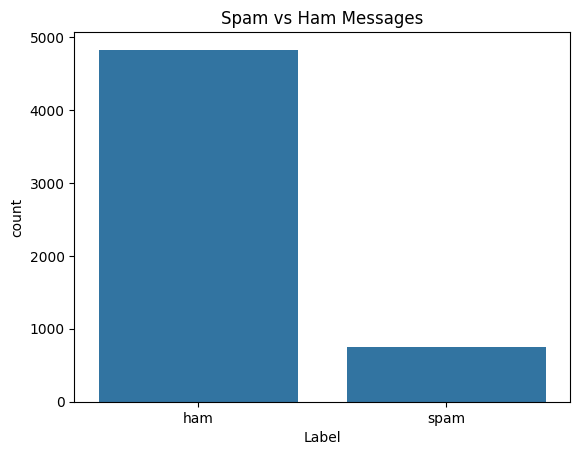

In [ ]:
sns.countplot(x='Label', data=df)

plt.title("Spam vs Ham Messages")

plt.show()

**Label Encoding**

In [ ]:
df['Label'] = df['Label'].map({
    'ham':0,
    'spam':1
})

In [ ]:
print(df['Label'].unique())

[0 1]


In [ ]:
df.head()

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
X = df['Message']

y = df['Label']

In [ ]:
print(X.head())

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Message, dtype: object


In [ ]:
print(y.head())

0    0
1    0
2    1
3    0
4    0
Name: Label, dtype: int64


**TF-IDF**

In [ ]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [ ]:
print(X.shape)

(5572, 8672)


**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (4457, 8672)
Testing Shape: (1115, 8672)


**Naive Bayes Model**

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

**Naive Bayes Evaluation**

In [ ]:
nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy: {nb_accuracy*100:.2f}%")

Naive Bayes Accuracy: 96.23%


In [ ]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [ ]:
cm = confusion_matrix(y_test, nb_pred)

print(cm)

[[965   0]
 [ 42 108]]


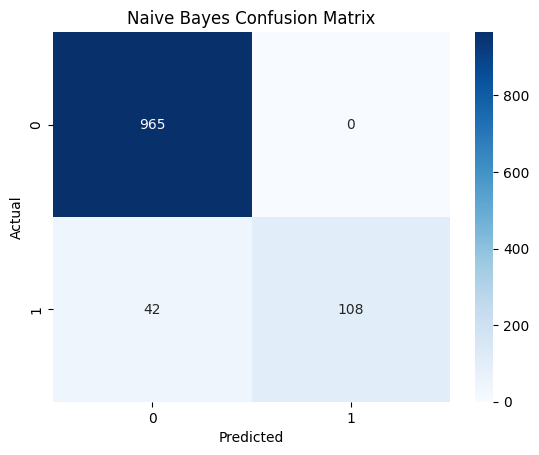

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Logistic Regression Model**

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

**Logistic Regression Evaluation**

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

Logistic Regression Accuracy: 96.32%


In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.73      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [ ]:
lr_cm = confusion_matrix(y_test, lr_pred)

print(lr_cm)

[[965   0]
 [ 41 109]]


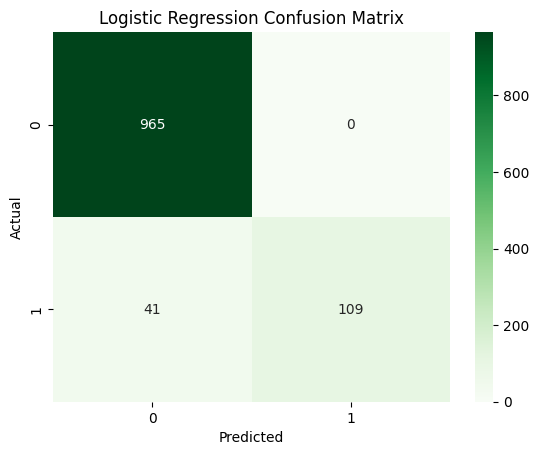

In [ ]:
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Support Vector Machine (SVM) Model**

In [ ]:
svm_model = SVC(kernel='linear')

In [ ]:
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

**SVM Evaluation**

In [ ]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_accuracy*100:.2f}%")

SVM Accuracy: 97.94%


In [ ]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
svm_cm = confusion_matrix(y_test, svm_pred)

print(svm_cm)

[[963   2]
 [ 21 129]]


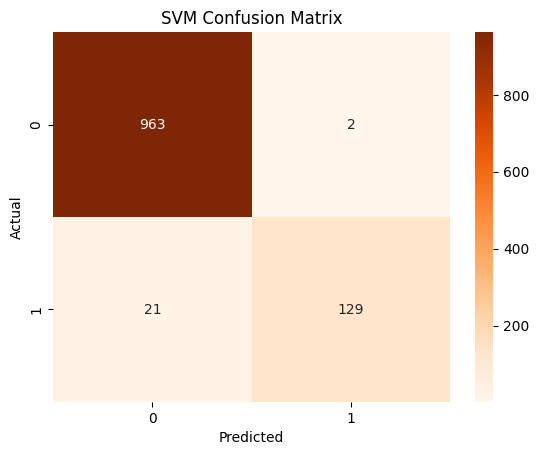

In [ ]:
sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Model Comparison**

Naive Bayes Accuracy: 96.23%
Logistic Regression Accuracy: 96.32%
SVM Accuracy: 97.94%


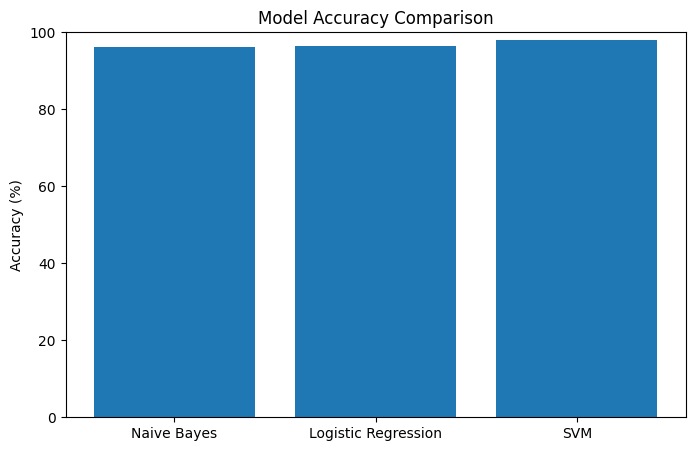

In [ ]:
models = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracies = [
    nb_accuracy * 100,
    lr_accuracy * 100,
    svm_accuracy * 100
]
print(f"Naive Bayes Accuracy: {nb_accuracy*100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"SVM Accuracy: {svm_accuracy*100:.2f}%")

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.show()